In [1]:
import pandas as pd
import numpy as np
import pickle

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

In [2]:
DATA_PATH = "final_dataset_with_weather.csv"

df = pd.read_csv(DATA_PATH)
df.columns = [c.strip() for c in df.columns]

print("Shape:", df.shape)
df.head()

Shape: (62195, 16)


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,cost_per_hectare,cost,Price,revenue,profit,risk,year,month,rainfall
0,Andaman and Nicobar Islands,NICOBARS,2010,Rabi,maize,3.84,18.22,30000.0,115200.0,1814.04,33051.8088,-8.214819e+04,High,NaN,NaN,NaN
1,Andaman and Nicobar Islands,NORTH AND MIDDLE ANDAMAN,2010,Rabi,groundnut,4.75,6.80,35000.0,166250.0,6552.61,44557.7480,-1.216923e+05,High,NaN,NaN,NaN
2,Andaman and Nicobar Islands,NORTH AND MIDDLE ANDAMAN,2010,Rabi,maize,86.70,96.40,30000.0,2601000.0,1814.04,174873.4560,-2.426127e+06,High,NaN,NaN,NaN
3,Andaman and Nicobar Islands,NORTH AND MIDDLE ANDAMAN,2010,Rabi,sunflower,2.90,1.90,35000.0,101500.0,6477.16,12306.6040,-8.919340e+04,High,NaN,NaN,NaN
4,Andaman and Nicobar Islands,SOUTH ANDAMANS,2010,Rabi,groundnut,15.50,7.60,35000.0,542500.0,6552.61,49799.8360,-4.927002e+05,High,NaN,NaN,NaN


In [3]:
# Sort by time first
df = df.sort_values(by=["year", "month"])

# Lag features
df["rainfall_lag1"] = df.groupby(["State_Name", "Crop"])["rainfall"].shift(1)
df["rainfall_lag2"] = df.groupby(["State_Name", "Crop"])["rainfall"].shift(2)

df["rainfall_roll3"] = (
    df.groupby(["State_Name", "Crop"])["rainfall"]
    .transform(lambda x: x.rolling(3).mean())
)

# Fill NaNs
df[["rainfall_lag1", "rainfall_lag2", "rainfall_roll3"]] = \
    df[["rainfall_lag1", "rainfall_lag2", "rainfall_roll3"]].fillna(0)

df.head()

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,cost_per_hectare,cost,Price,revenue,profit,risk,year,month,rainfall,rainfall_lag1,rainfall_lag2,rainfall_roll3
139,Andhra Pradesh,ANANTAPUR,2014,Kharif,groundnut,550794.0,148714.0,35000.0,1.927779e+10,6552.61,9.744648e+08,-1.830333e+10,High,2014.0,1.0,0.0,0.0,0.0,0.0
151,Andhra Pradesh,ANANTAPUR,2014,Kharif,maize,16839.0,42687.0,30000.0,5.051700e+08,1814.04,7.743593e+07,-4.277341e+08,High,2014.0,1.0,0.0,0.0,0.0,0.0
163,Andhra Pradesh,ANANTAPUR,2014,Kharif,soyabean,44.0,50.0,35000.0,1.540000e+06,5636.12,2.818060e+05,-1.258194e+06,High,2014.0,1.0,0.0,0.0,0.0,0.0
175,Andhra Pradesh,ANANTAPUR,2014,Kharif,sunflower,5066.0,1180.0,35000.0,1.773100e+08,6477.16,7.643049e+06,-1.696670e+08,High,2014.0,1.0,0.0,0.0,0.0,0.0
187,Andhra Pradesh,ANANTAPUR,2014,Rabi,groundnut,14957.0,24679.0,35000.0,5.234950e+08,6552.61,1.617119e+08,-3.617831e+08,High,2014.0,1.0,0.0,0.0,0.0,0.0


In [4]:
df = df.dropna(subset=["Production", "Area"])

for col in ["Production", "Area", "Price", "cost_per_hectare", "rainfall"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df.isna().sum()

State_Name              0
District_Name           0
Crop_Year               0
Season                  0
Crop                    0
Area                    0
Production              0
cost_per_hectare        0
cost                    0
Price                   0
revenue                 0
profit                  0
risk                    0
year                38423
month               38423
rainfall            38423
rainfall_lag1           0
rainfall_lag2           0
rainfall_roll3          0
dtype: int64

In [5]:
df["yield_per_hectare"] = df["Production"] / df["Area"].replace(0, np.nan)

df["revenue"] = df["yield_per_hectare"] * df["Price"]
df["profit"] = df["revenue"] - df["cost_per_hectare"]

df["p33"] = df.groupby("Crop")["profit"].transform(lambda x: x.quantile(0.33))
df["p67"] = df.groupby("Crop")["profit"].transform(lambda x: x.quantile(0.67))

def assign_risk(row):
    if row["profit"] < row["p33"]:
        return 2   # High Risk
    elif row["profit"] < row["p67"]:
        return 1   # Medium Risk
    else:
        return 0   # Low Risk

df["financial_risk"] = df.apply(assign_risk, axis=1)

df = df.dropna(subset=["financial_risk"])

df["financial_risk"].value_counts()

financial_risk
1    21072
0    20618
2    20505
Name: count, dtype: int64

In [6]:
# 🌦️ Seasonal encoding (VERY powerful)

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

df.head()

,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production,cost_per_hectare,cost,Price,...,rainfall,rainfall_lag1,rainfall_lag2,rainfall_roll3,yield_per_hectare,p33,p67,financial_risk,month_sin,month_cos
139,Andhra Pradesh,ANANTAPUR,2014,Kharif,groundnut,550794.0,148714.0,35000.0,1.927779e+10,6552.61,...,0.0,0.0,0.0,0.0,0.269999,-29096.858319,-26407.474823,2,0.5,0.866025
151,Andhra Pradesh,ANANTAPUR,2014,Kharif,maize,16839.0,42687.0,30000.0,5.051700e+08,1814.04,...,0.0,0.0,0.0,0.0,2.535008,-27170.097600,-25464.900000,0,0.5,0.866025
163,Andhra Pradesh,ANANTAPUR,2014,Kharif,soyabean,44.0,50.0,35000.0,1.540000e+06,5636.12,...,0.0,0.0,0.0,0.0,1.136364,-30535.714505,-28397.688000,1,0.5,0.866025
175,Andhra Pradesh,ANANTAPUR,2014,Kharif,sunflower,5066.0,1180.0,35000.0,1.773100e+08,6477.16,...,0.0,0.0,0.0,0.0,0.232925,-31221.656667,-27676.392955,2,0.5,0.866025
187,Andhra Pradesh,ANANTAPUR,2014,Rabi,groundnut,14957.0,24679.0,35000.0,5.234950e+08,6552.61,...,0.0,0.0,0.0,0.0,1.649997,-29096.858319,-26407.474823,0,0.5,0.866025


In [7]:
SAFE_NUMERIC = [
    "rainfall",
    "rainfall_lag1",
    "rainfall_lag2",
    "rainfall_roll3",
    "year",
    "month"
]
SAFE_CATEGORICAL = ["State_Name", "District_Name", "Season", "Crop"]

# Encode categorical features
le_dict = {}

for col in SAFE_CATEGORICAL:
    le = LabelEncoder()
    df[col + "_enc"] = le.fit_transform(df[col].astype(str))
    le_dict[col] = le

feature_cols = SAFE_NUMERIC + [c + "_enc" for c in SAFE_CATEGORICAL]

# Sort by time (VERY IMPORTANT)
df = df.sort_values(by=["year", "month"])

X = df[feature_cols].fillna(0)
y = df["financial_risk"]

print("Features:", feature_cols)
print("Shape:", X.shape)

Features: ['rainfall', 'rainfall_lag1', 'rainfall_lag2', 'rainfall_roll3', 'year', 'month', 'State_Name_enc', 'District_Name_enc', 'Season_enc', 'Crop_enc']
Shape: (62195, 10)


In [9]:
tscv = TimeSeriesSplit(n_splits=5)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

acc_scores = []
auc_scores = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    acc = accuracy_score(y_test, y_pred)
    acc_scores.append(acc)

    try:
        auc = roc_auc_score(y_test, y_prob, multi_class="ovr")
        auc_scores.append(auc)
    except:
        pass

    print(f"Fold {fold+1}: Accuracy = {acc:.4f}")

print("\nAverage Accuracy:", np.mean(acc_scores))

if auc_scores:
    print("Average AUC:", np.mean(auc_scores))

Fold 1: Accuracy = 0.7243
Fold 2: Accuracy = 0.5383
Fold 3: Accuracy = 0.4419
Fold 4: Accuracy = 0.5087
Fold 5: Accuracy = 0.3849

Average Accuracy: 0.5195947901591895
Average AUC: 0.6843377658858054


In [11]:
model.fit(X, y)

with open("final_leakage_free_model.pkl", "wb") as f:
    pickle.dump({
        "model": model,
        "features": feature_cols,
        "encoders": le_dict
    }, f)

print("✅ Model saved!")

✅ Model saved!


In [12]:
y_pred = model.predict(X)

print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.73      0.74     20618
           1       0.66      0.48      0.56     21072
           2       0.62      0.81      0.71     20505

    accuracy                           0.67     62195
   macro avg       0.68      0.68      0.67     62195
weighted avg       0.68      0.67      0.67     62195



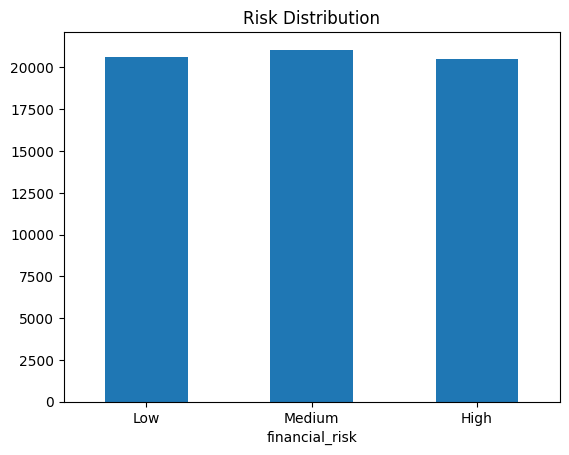

In [13]:
import matplotlib.pyplot as plt

df["financial_risk"].value_counts().sort_index().plot(kind="bar")
plt.xticks([0,1,2], ["Low", "Medium", "High"], rotation=0)
plt.title("Risk Distribution")
plt.show()

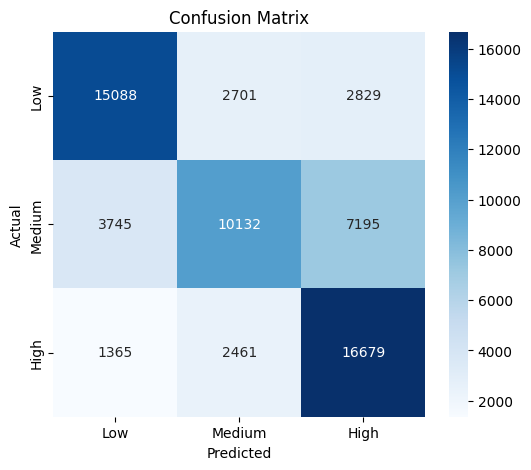

In [14]:
#confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = model.predict(X)

cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Low", "Medium", "High"],
            yticklabels=["Low", "Medium", "High"])

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [15]:
#Classification Report (Clean Table)
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y, y_pred, output_dict=True)

report_df = pd.DataFrame(report).transpose()
report_df

,precision,recall,f1-score,support
0,0.747005,0.731788,0.739318,20618.000000
1,0.662482,0.480828,0.557224,21072.000000
2,0.624611,0.813411,0.706618,20505.000000
accuracy,0.673672,0.673672,0.673672,0.673672
macro avg,0.678033,0.675342,0.667720,62195.000000
weighted avg,0.678016,0.673672,0.666842,62195.000000


In [17]:
#Feature Importance
import pandas as pd

importances = model.feature_importances_

feat_df = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

feat_df.head(15)

,Feature,Importance
6,State_Name_enc,0.434994
9,Crop_enc,0.203437
8,Season_enc,0.164300
7,District_Name_enc,0.142372
4,year,0.018398
5,month,0.013964
3,rainfall_roll3,0.006582
2,rainfall_lag2,0.005607
1,rainfall_lag1,0.005232
0,rainfall,0.005114


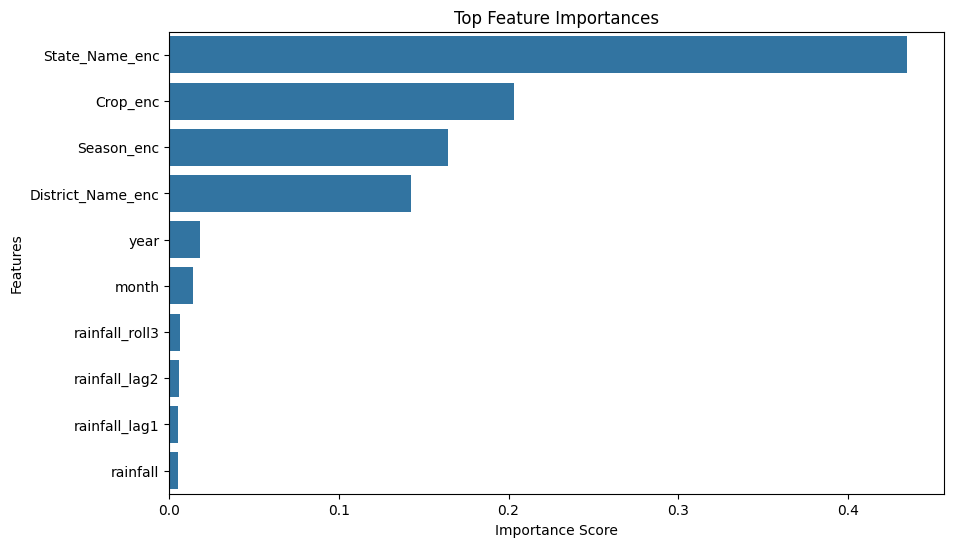

In [18]:
#Feature Importance Plot
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feat_df.head(10)
)

plt.title("Top Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

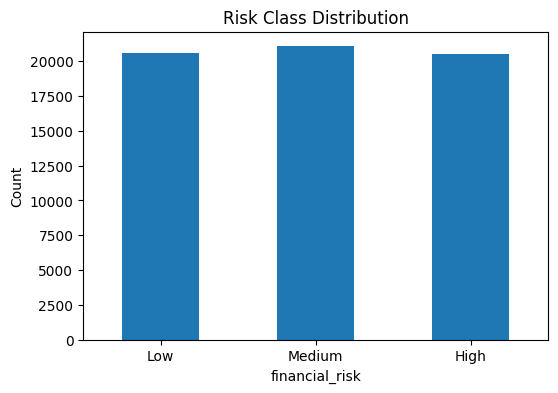

In [19]:
#Class Distribution
df["financial_risk"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(6,4)
)

plt.xticks([0,1,2], ["Low", "Medium", "High"], rotation=0)
plt.title("Risk Class Distribution")
plt.ylabel("Count")
plt.show()

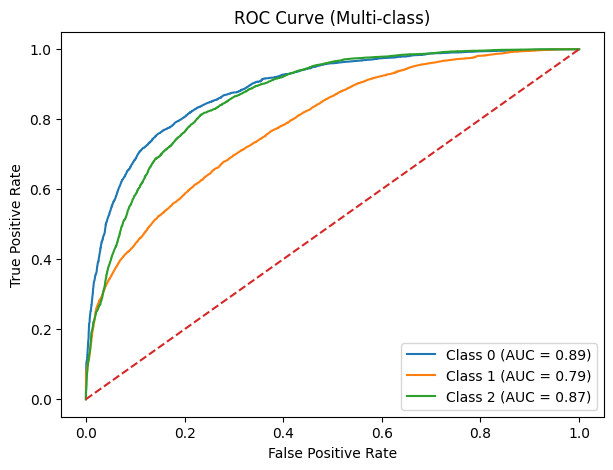

In [20]:
#ROC Curve
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

y_bin = label_binarize(y, classes=[0,1,2])
y_prob = model.predict_proba(X)

plt.figure(figsize=(7,5))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], linestyle="--")
plt.title("ROC Curve (Multi-class)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

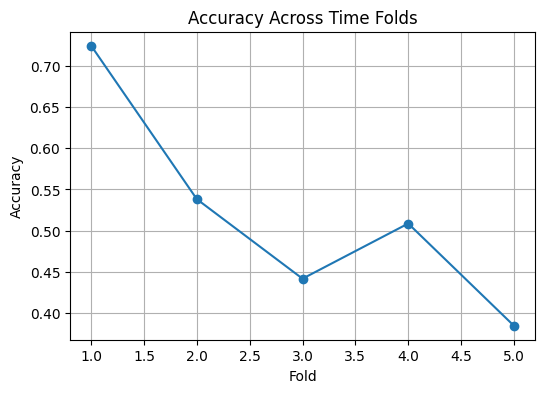

In [21]:
#Accuracy Across Folds
plt.figure(figsize=(6,4))

plt.plot(range(1, len(acc_scores)+1), acc_scores, marker="o")

plt.title("Accuracy Across Time Folds")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.grid()

plt.show()

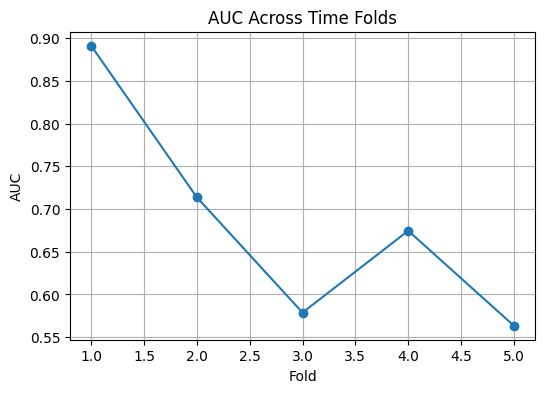

In [22]:
# AUC Across Folds
if auc_scores:
    plt.figure(figsize=(6,4))
    
    plt.plot(range(1, len(auc_scores)+1), auc_scores, marker="o")
    
    plt.title("AUC Across Time Folds")
    plt.xlabel("Fold")
    plt.ylabel("AUC")
    plt.grid()
    
    plt.show()

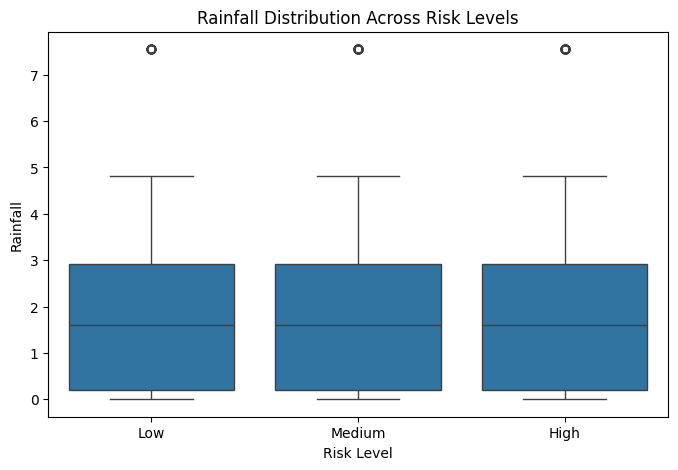

In [23]:
#Rainfall vs Risk
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(x=df["financial_risk"], y=df["rainfall"])

plt.xticks([0,1,2], ["Low", "Medium", "High"])
plt.title("Rainfall Distribution Across Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Rainfall")

plt.show()

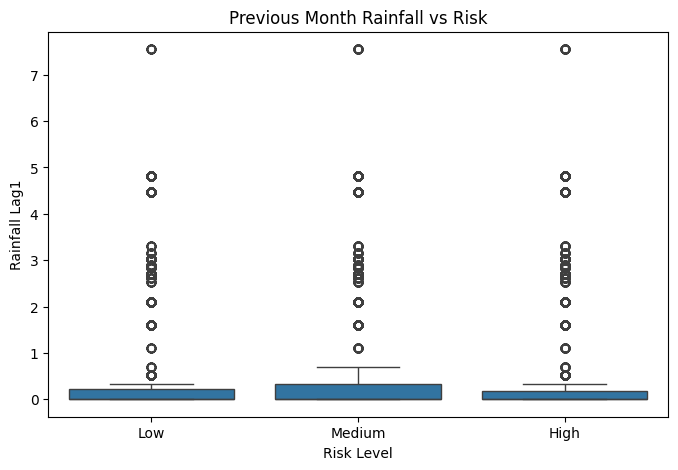

In [24]:
#Lag Feature Impact
plt.figure(figsize=(8,5))

sns.boxplot(x=df["financial_risk"], y=df["rainfall_lag1"])

plt.xticks([0,1,2], ["Low", "Medium", "High"])
plt.title("Previous Month Rainfall vs Risk")
plt.xlabel("Risk Level")
plt.ylabel("Rainfall Lag1")

plt.show()

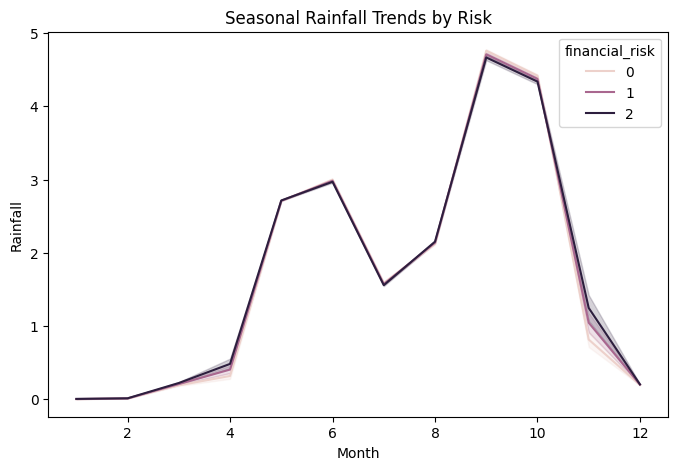

In [25]:
#Seasonal Pattern
plt.figure(figsize=(8,5))

sns.lineplot(
    x="month",
    y="rainfall",
    hue="financial_risk",
    data=df
)

plt.title("Seasonal Rainfall Trends by Risk")
plt.xlabel("Month")
plt.ylabel("Rainfall")

plt.show()

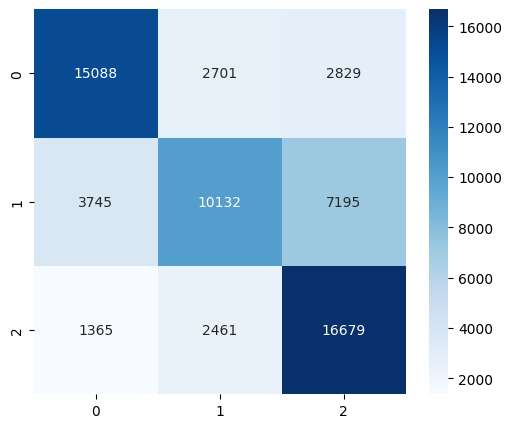

In [26]:
# Example save
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.savefig("confusion_matrix.png", dpi=300)

In [27]:
import pickle

data = pickle.load(open("final_leakage_free_model.pkl", "rb"))
print(type(data))
print(data.keys())

<class 'dict'>
dict_keys(['model', 'features', 'encoders'])
